In [12]:
import re
import random
import os
from pathlib import Path
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def randomNetlist(filename):

    base, ext = os.path.splitext(filename)
    new_filename = f"{base}_mod{ext}"
    counter = 1
    while os.path.exists(new_filename):
        new_filename = f"{base}_mod_{counter}{ext}"
        counter += 1

    pattern_1 = re.compile(r"^R[1-5][1-5]_1\b")
    pattern_6 = re.compile(r"^R[1-5][1-5]_6\b")
    pattern_9 = re.compile(r"^R[1-5]_9\b")

    with open(filename, "r", encoding="utf-8") as f:
        lines = f.readlines()

    num_random_1 = []
    new_lines = []

    for line in lines:
        parts = line.strip().split()

        if len(parts) == 4 and pattern_1.match(parts[0]): # Se elige al azar una fuente para todos las entradas sub 1
            num = random.randint(0, 3)
            num_random_1.append(num)
            match num:
                case 0: estado_input_1 = "VcON"
                case 1: estado_input_1 = "VcOFF"
                case 2: estado_input_1 = "VcMAS"
                case 3: estado_input_1 = "VcMENOS"
            parts[2] = estado_input_1
            new_lines.append(" ".join(parts) + "\n")

        elif len(parts) == 4 and pattern_6.match(parts[0]): # Se eligen las fuente para las entradas sub 6 según cuáles fueron elegidas en las sub 1
            match num_random_1[-1]:
                case 0: estado_input_6 = "VcOFF"
                case 1: estado_input_6 = "VcON"
                case 2: estado_input_6 = "VcMENOS"
                case 3: estado_input_6 = "VcMAS"
            parts[2] = estado_input_6
            new_lines.append(" ".join(parts) + "\n")

        elif len(parts) == 4 and pattern_9.match(parts[0]): # En caso que sean todas iguales las entradas del banco se define la entrada sub 9 correspondiente
            match num_random_1:
                case [0, 0, 0, 0, 0]: estado_input_9 = "VcOFF"
                case [1, 1, 1, 1, 1]: estado_input_9 = "VcON"
                case [2, 2, 2, 2, 2]: estado_input_9 = "VcMENOS"
                case [3, 3, 3, 3, 3]: estado_input_9 = "VcMAS"
                case _: estado_input_9 = "VcOFF"
            parts[2] = estado_input_9
            new_lines.append(" ".join(parts) + "\n")
            num_random_1.clear()

        else:
            new_lines.append(line)

    with open(new_filename, "w", encoding="utf-8") as f:
        f.writelines(new_lines)

In [9]:
def ejecutarSimulacionesXyce(folder, xyce_exe):

    p = Path(folder)
    if not p.is_dir():
        raise SystemExit(f"Carpeta no encontrada: {p}")

    cir_files = sorted([f for f in p.iterdir() if f.suffix.lower() == ".cir"])
    if not cir_files:
        print("Ningún archivo .cir encontrado")
        raise SystemExit

    for cir in cir_files:
        print(f"\n=== Ejecutando Xyce en: {cir.name} ===")
        cmd = [xyce_exe, str(cir.name)]
        try:
            # Run command, show output live in the console
            result = subprocess.run(cmd, cwd=str(p))
            if result.returncode == 0:
                print(f"Simulación OK: {cir.name}")
            else:
                print(f"Error ({result.returncode}) en {cir.name}")
        except FileNotFoundError:
            print(f"Executable not found: {xyce_exe}. Check your path.")
            break
        except Exception as e:
            print("Unexpected error:", e)
            break

In [ ]:
cantidad_variante_netlist = 5
for i in range(cantidad_variante_netlist):
    randomNetlist(r"C:\Users\Sebas\Desktop\Matriz 5x5\Netlist5x5.cir")

folder = r"C:\Users\Sebas\Desktop\Matriz 5x5"
xyce_exe = r"C:\Program Files\XyceNF_7.10\bin\Xyce.exe"
ejecutarSimulacionesXyce(folder, xyce_exe)


=== Ejecutando Xyce en: Netlist5x5.cir ===
Simulación OK: Netlist5x5.cir

=== Ejecutando Xyce en: Netlist5x5_mod.cir ===
Simulación OK: Netlist5x5_mod.cir

=== Ejecutando Xyce en: Netlist5x5_mod_1.cir ===
Simulación OK: Netlist5x5_mod_1.cir

=== Ejecutando Xyce en: Netlist5x5_mod_2.cir ===
Simulación OK: Netlist5x5_mod_2.cir

=== Ejecutando Xyce en: Netlist5x5_mod_3.cir ===
Simulación OK: Netlist5x5_mod_3.cir

=== Ejecutando Xyce en: Netlist5x5_mod_4.cir ===
Simulación OK: Netlist5x5_mod_4.cir


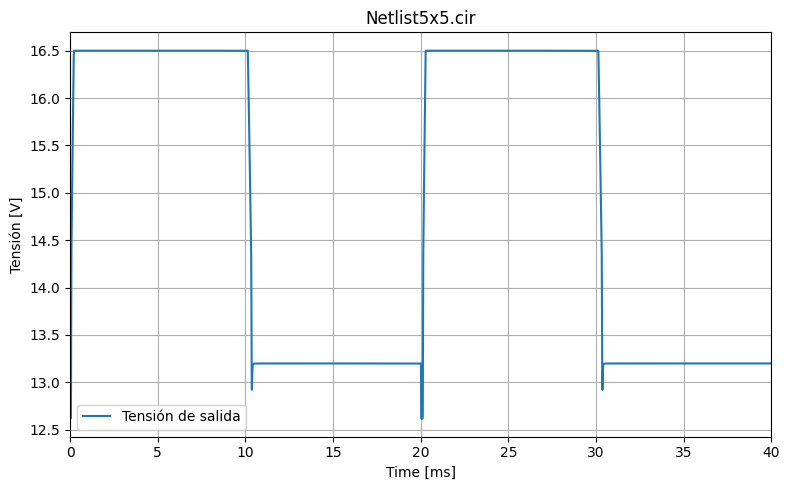

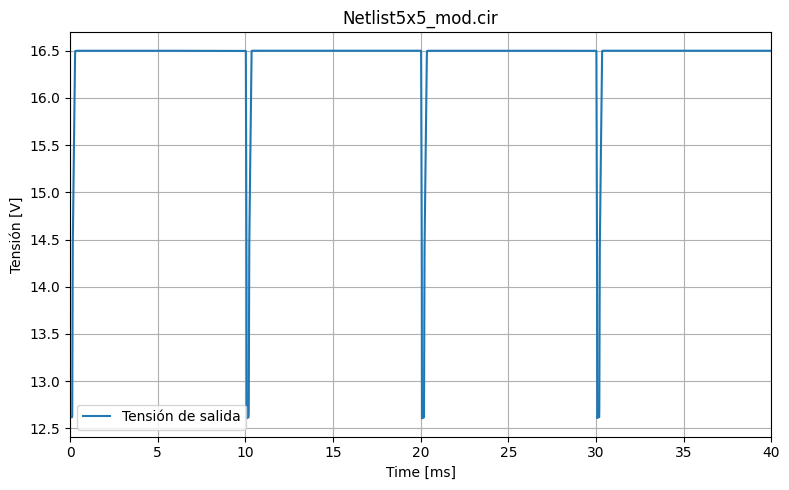

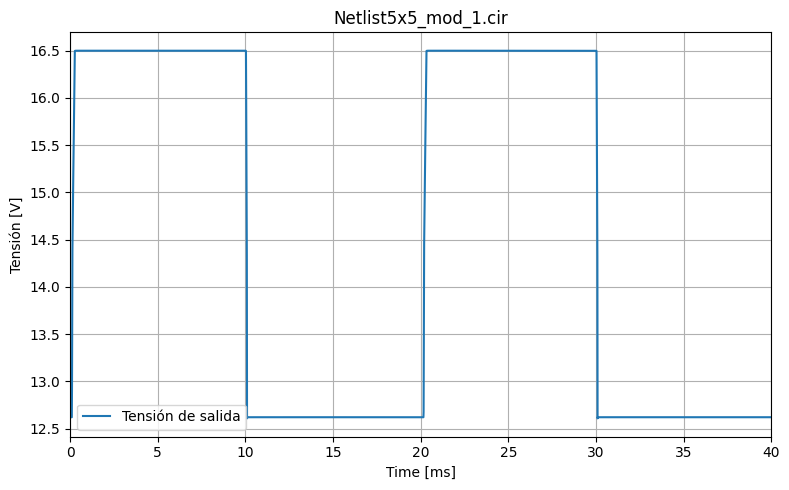

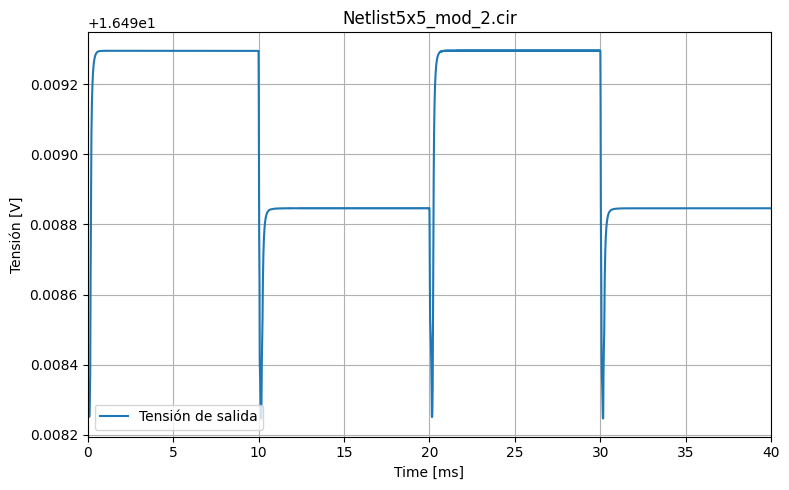

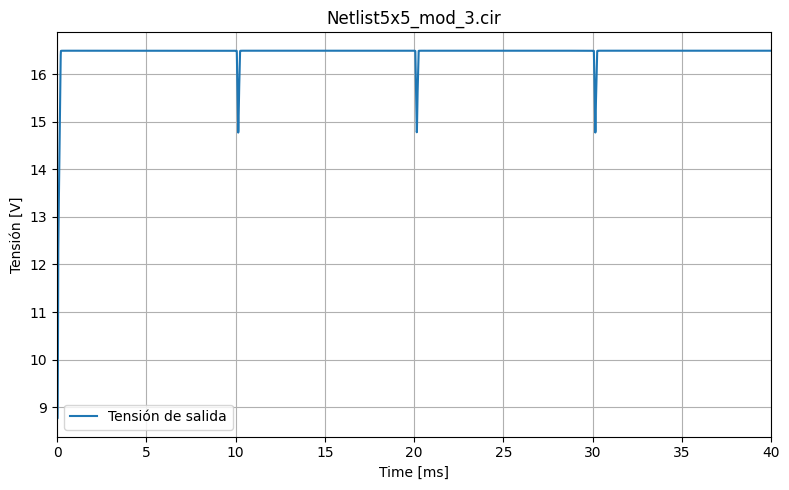

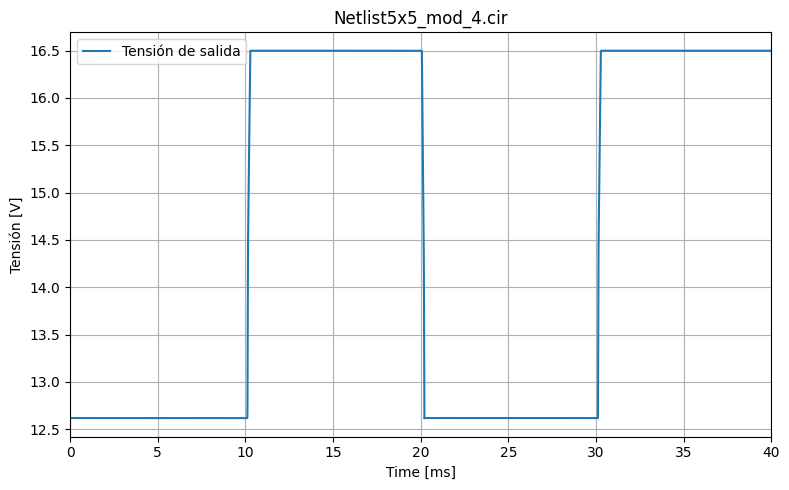

In [ ]:
# Folder containing your .prn files
folder = Path(r"C:\Users\Sebas\Desktop\Matriz 5x5")

# --- LOOP THROUGH ALL .prn FILES ---
for file in folder.glob("*.prn"):
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        # Skip footer line(s)
        lines = [line for line in f if not line.startswith("End of Xyce")]

    # Load into DataFrame
    df = pd.read_csv(StringIO("".join(lines)), sep=r"\s+", engine="python")
    df.columns = ["Index", "Tiempo", "Tensión de salida"]

    # Extract columns
    time = df["Tiempo"] * 1e3
    voltage_cols = [col for col in df.columns if col.startswith("Ten")]

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    for col in voltage_cols:
        plt.plot(time, df[col], label=col)

    plt.xlim(0, 40)
    plt.xlabel("Time [ms]")
    plt.ylabel("Tensión [V]")
    plt.title(f"{file.stem}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()